(pie_example)=
# Predicted Incrementality by Experimentation (PIE)

Randomised controlled trials (RCTs) such as geo experiments and ghost-ad holdouts are the gold standard for measuring the incrementality of an ad campaign. However, they are also expensive and slow, so even experiment-focussed advertisers experiment on only a fraction of their campaigns. Often, the remaining campaigns are measured by attribution proxies such as last-click conversions, which measure proximity to intent, not causation.

Predicted Incrementality by Experimentation (PIE), introduced by [Gordon, Moakler & Zettelmeyer (2026)](https://www.nber.org/papers/w35044), stretches the measured fraction across the whole portfolio. The PIE approach first fits a supervised model on the corpus of campaigns that did run an RCT to learn the map from observable campaign features $x_i$ to experimentally measured incrementality $\tau_i$,

$$\tau_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathrm{Normal}(0, \sigma).$$

Once the model's parameters have been inferred from the observed RCT measurements, incrementality is predicted for those campaigns that never ran an experiment. {class}`~pymc_marketing.pie.PIEModel` implements this idea with Bayesian Additive Regression Trees (BART). This means that $f$ is sampled rather than point-estimated and every prediction is a full posterior, thus allowing us to fully capture the uncertainty innate to the PIE predictions. 

In this notebook we build a simulated world in which the truth is known and use it to expose the internals of PIE via

1. We simulate a corpus of 1,000 RCT-measured campaigns whose last-click metrics are systematically misleading
2. Fit `PIEModel` on the corpus
3. Inspect the model to learn which features drive incrementality and how predicted incrementality saturates with budget
4. Predict incrementality for 300 campaigns that never ran an experiment, scoring the predictions against the simulated truth.
5. Pick 60 campaigns to scale up. Choosing by last-click sends the budget to the least incremental campaigns in the portfolio, while choosing by PIE's predictions identifies almost all of the campaigns with the highest true incrementality.

```{note}
The `pymc_marketing.pie` module is **alpha**: the API and defaults may change, and several components of the paper are not yet implemented. The differences are summarised at the end of this notebook.
```

## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc_bart as pmb
from scipy import stats

from pymc_marketing.pie import PIEModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "pie"))
rng: np.random.Generator = np.random.default_rng(seed)

## Simulating a Corpus of Experiments

[Gordon, Moakler & Zettelmeyer (2026)](https://www.nber.org/papers/w35044) train a PIE model on 2,226 real RCTs run on Meta. Those data are proprietary, so we simulate a corpus that shares their key structural features, one where we know the true incrementality of every campaign. Of course, in practice, no practitioner ever has access to the true incrementality; however, for the purposes of this notebook, knowing the true incrementality gives a way to assess the PIE model's quality. Throughout, incrementality is measured in incremental conversions per dollar of spend.

Each campaign carries the features used as the running example in the `PIEModel` docstring:

| Feature | Values | Known… |
|---|---|---|
| `objective` | conversions / traffic / awareness | before launch (*pre-determined*) |
| `vertical` | retail / travel / finance / cpg / tech | before launch (*pre-determined*) |
| `audience_type` | prospecting / retargeting | before launch (*pre-determined*) |
| `budget` | dollars | before launch (*pre-determined*) |
| `exposure_rate` | share of the target audience reached | after the campaign (*post-determined*) |
| `ctr` | click-through rate | after the campaign (*post-determined*) |
| `last_click_conversions_per_dollar` | attribution proxy | after the campaign (*post-determined*) |

The ground-truth incrementality function is non-linear with interactions:

- Audience type is the dominant driver. Prospecting campaigns reach people who would not otherwise have converted, while retargeting campaigns reach people already close to converting, so their incremental effect is small.
- Incrementality saturates with budget. Above roughly \$25k, each additional dollar of spend reaches a less receptive audience and produces fewer incremental conversions.
- A higher exposure rate raises incrementality for both audience types, but the effect is about four times stronger for prospecting campaigns than for retargeting campaigns.
- The campaign objective scales incrementality up or down, and the industry vertical adds a small offset.

Within this simulation we also incorporate the problem central to this notebook - the last-click proxy rewards the wrong campaigns. Last-click attribution credits a conversion to the last ad the customer clicked before buying. Retargeting campaigns target people who are already likely to buy, so a retargeting ad is often that last click, and the campaign gets credit for a purchase that would have happened anyway. In the simulation, each campaign's last-click conversions per dollar are $0.4\,\tau$, plus a constant and additive noise. The $0.4\,\tau$ term means the metric partly tracks true incrementality. The constant is 0.9 for retargeting campaigns and 0.05 for prospecting campaigns, and represents the conversions that are credited to the campaign but would have happened anyway. `ctr` has no causal effect on incrementality; however, we include it to check that the model learns to ignore an irrelevant feature.

Finally, in practice, any one RCT gives a noisy estimate of $\hat{\tau} = \tau + \mathcal{N}(0, 0.3^2)$. For the purpose of this notebook, we set the measurement noise term $\sigma_{\mathrm{RCT}}$ as 0.3.

In [2]:
OBJECTIVES = ["conversions", "traffic", "awareness"]
VERTICALS = ["retail", "travel", "finance", "cpg", "tech"]
AUDIENCES = ["prospecting", "retargeting"]

OBJECTIVE_MULT = {"conversions": 1.0, "traffic": 0.75, "awareness": 0.5}
VERTICAL_SHIFT = {
    "retail": 0.06,
    "travel": 0.0,
    "finance": -0.05,
    "cpg": 0.03,
    "tech": -0.03,
}
CTR_BASE = {"conversions": 0.015, "traffic": 0.05, "awareness": 0.008}

SIGMA_RCT = 0.3  # std of RCT measurement noise


def true_incrementality(objective, vertical, audience_type, budget, exposure_rate):
    """Ground-truth incremental conversions per dollar — known only because we simulate."""
    is_retargeting = np.asarray(audience_type, dtype=object) == "retargeting"
    objective_mult = (
        pd.Series(np.asarray(objective, dtype=object)).map(OBJECTIVE_MULT).to_numpy()
    )
    vertical_shift = (
        pd.Series(np.asarray(vertical, dtype=object)).map(VERTICAL_SHIFT).to_numpy()
    )
    audience_base = np.where(is_retargeting, 0.25, 0.85)
    exposure_lift = np.asarray(exposure_rate) * np.where(is_retargeting, 0.15, 0.65)
    saturation = np.exp(
        -0.4 * np.clip(np.log(np.asarray(budget)) - np.log(25_000.0), 0.0, None)
    )
    tau = objective_mult * (audience_base + exposure_lift) * saturation + vertical_shift
    return np.clip(tau, 0.02, None)


def simulate_campaigns(
    n: int, rng: np.random.Generator, prefix: str
) -> tuple[pd.DataFrame, pd.Series]:
    """Simulate a portfolio of n campaigns; return (features X, true incrementality tau)."""
    objective = rng.choice(OBJECTIVES, size=n, p=[0.5, 0.3, 0.2])
    vertical = rng.choice(VERTICALS, size=n)
    audience_type = rng.choice(AUDIENCES, size=n, p=[0.55, 0.45])
    budget = np.exp(rng.normal(10.0, 0.8, size=n)).round(0)
    is_retargeting = audience_type == "retargeting"
    exposure_rate = rng.beta(
        np.where(is_retargeting, 6.0, 3.0),
        np.where(is_retargeting, 3.0, 4.0),
    )
    ctr = np.array([CTR_BASE[o] for o in objective]) * np.exp(
        rng.normal(0.0, 0.35, size=n)
    )

    tau = true_incrementality(objective, vertical, audience_type, budget, exposure_rate)

    # The proxy: partially informative, systematically biased toward retargeting.
    attribution_bias = np.where(is_retargeting, 0.9, 0.05)
    last_click = 0.4 * tau + attribution_bias + rng.normal(0.0, 0.07, size=n)

    index = pd.Index([f"{prefix}{i:04d}" for i in range(n)], name="campaign")
    X = pd.DataFrame(
        {
            "objective": objective,
            "vertical": vertical,
            "audience_type": audience_type,
            "budget": budget,
            "exposure_rate": exposure_rate,
            "ctr": ctr,
            "last_click_conversions_per_dollar": last_click,
        },
        index=index,
    )
    return X, pd.Series(tau, index=index, name="true_incrementality")

We generate the corpus of 1,000 measured campaigns and a further 300 campaigns that never ran an experiment. For the measured campaigns we observe only the noisy RCT reading `y_rct`; the true values `tau_rct` and `tau_new` exist purely because this is a simulation, and we will use them only to evaluate the model. We also draw `y_new_hypothetical` (the readings RCTs would have produced on the unmeasured campaigns) for a comparison later on.

In [3]:
X_rct, tau_rct = simulate_campaigns(1_000, rng, prefix="c")
X_new, tau_new = simulate_campaigns(300, rng, prefix="u")

y_rct = tau_rct + rng.normal(0.0, SIGMA_RCT, size=len(tau_rct))
y_new_hypothetical = tau_new + rng.normal(0.0, SIGMA_RCT, size=len(tau_new))

X_rct.head()

,objective,vertical,audience_type,budget,exposure_rate,ctr,last_click_conversions_per_dollar
campaign,,,,,,,
c0000,awareness,cpg,prospecting,15175.0,0.443946,0.009926,0.364945
c0001,traffic,cpg,retargeting,31440.0,0.806335,0.055666,0.911358
c0002,awareness,travel,prospecting,26498.0,0.262732,0.006914,0.341000
c0003,conversions,tech,retargeting,25446.0,0.796356,0.021473,0.981408
c0004,conversions,cpg,prospecting,135377.0,0.780527,0.008001,0.307803


### Comparing Last-Click Against True Incrementality

Before fitting any model, it is useful to plot the simulated corpus. The left panel below shows that prospecting campaigns have much higher true incrementality than retargeting campaigns. The right panel plots each campaign's last-click metric against its true incrementality, and shows that last-click ranks the two groups in the opposite order. This reversal happens because the conversions that are falsely credited to retargeting campaigns are larger than the $0.4\,\tau$ component of the metric that tracks true incrementality.

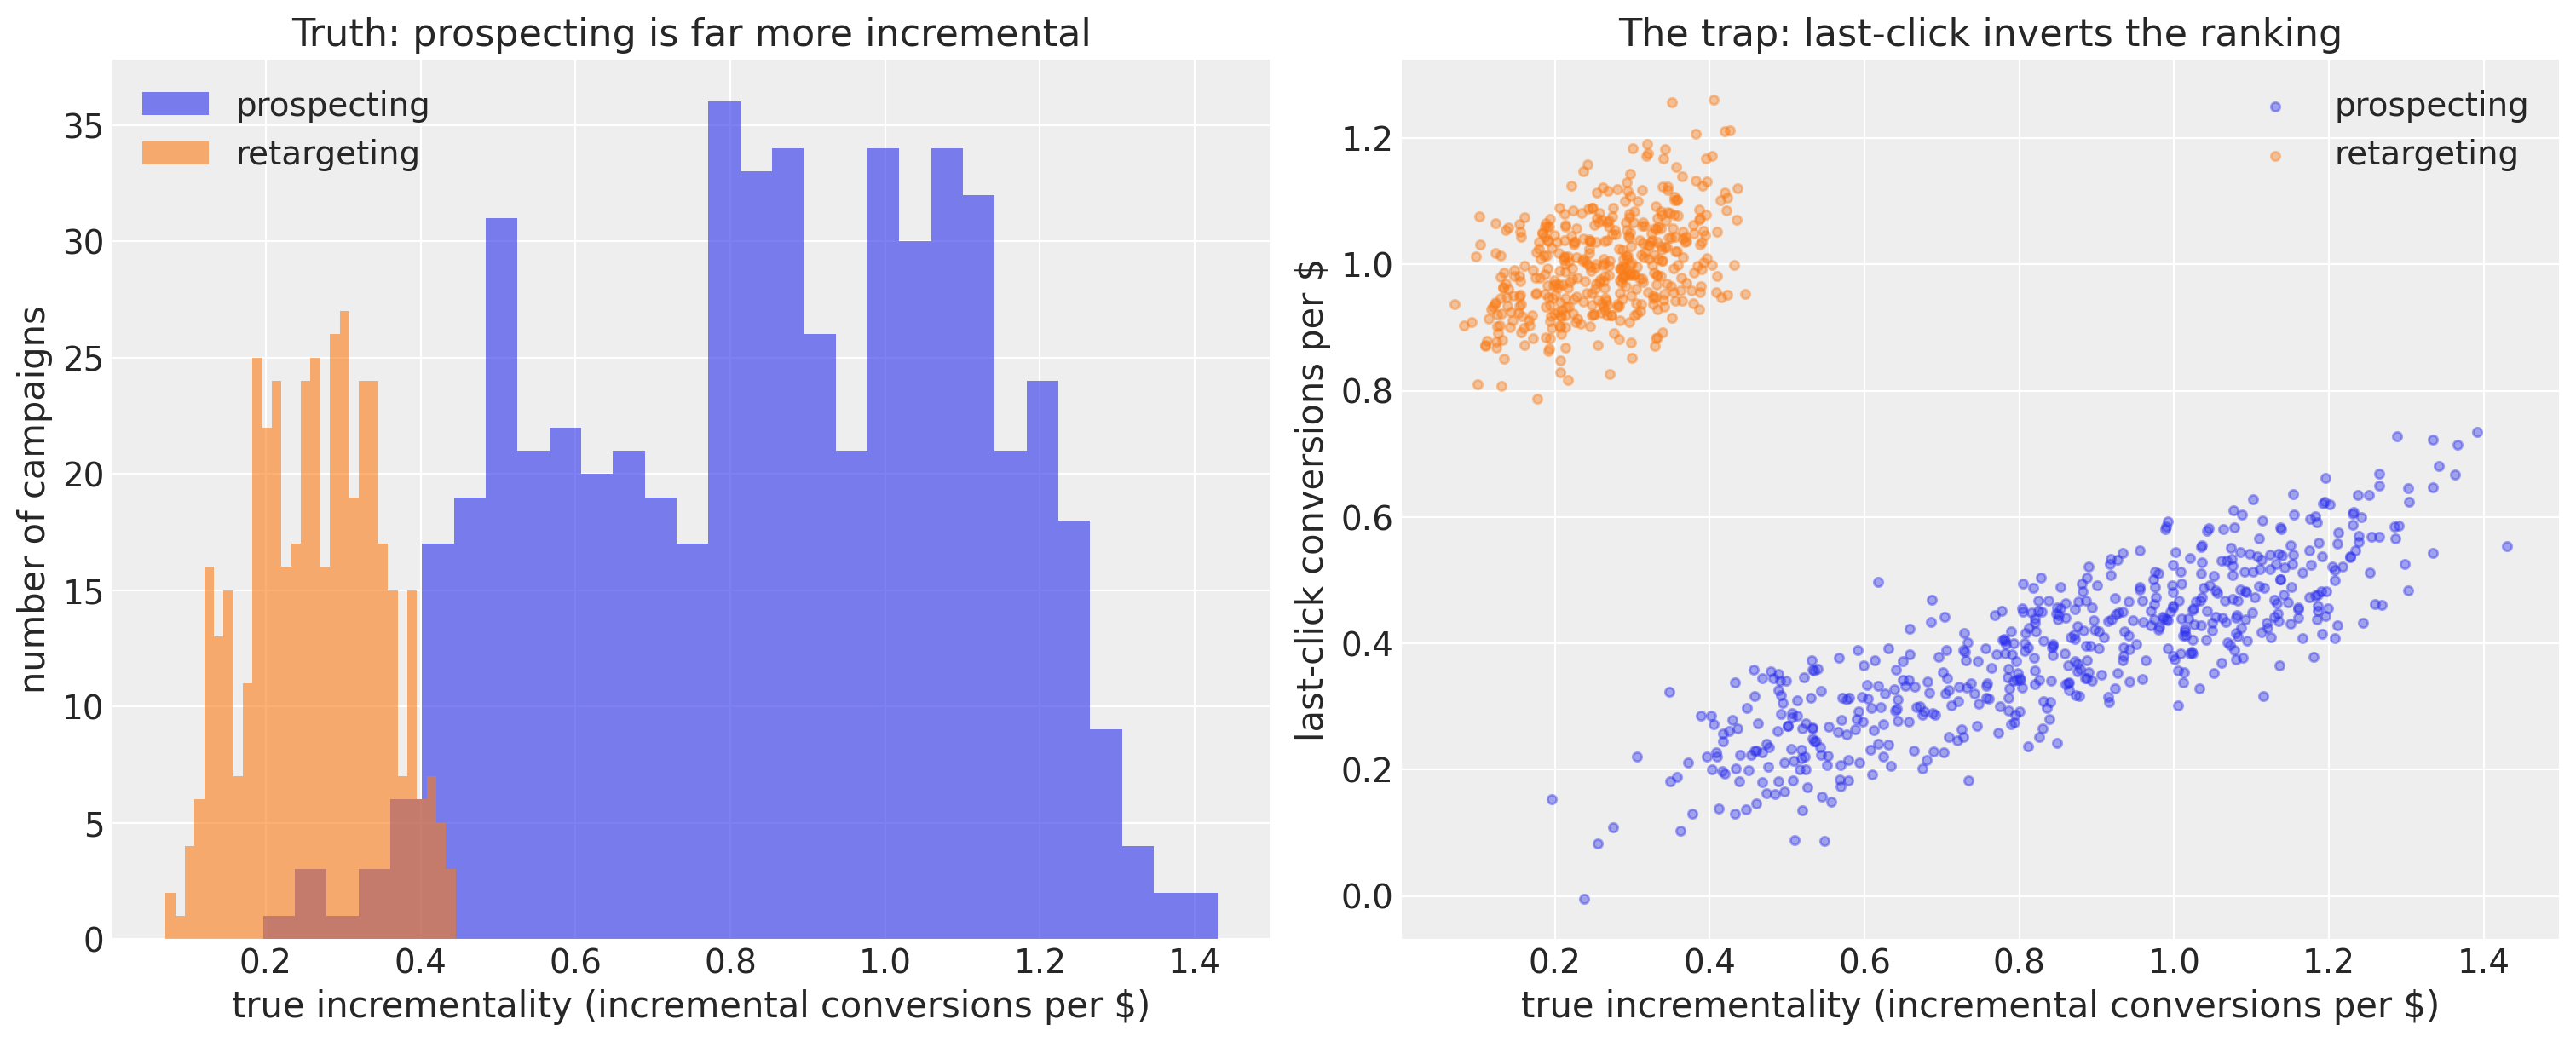

In [4]:
colors = {"prospecting": "C0", "retargeting": "C1"}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
for audience, color in colors.items():
    mask = X_rct["audience_type"] == audience
    axes[0].hist(tau_rct[mask], bins=30, alpha=0.6, color=color, label=audience)
    axes[1].scatter(
        tau_rct[mask],
        X_rct.loc[mask, "last_click_conversions_per_dollar"],
        alpha=0.4,
        s=14,
        color=color,
        label=audience,
    )
axes[0].set(
    xlabel="true incrementality (incremental conversions per $)",
    ylabel="number of campaigns",
    title="Truth: prospecting is far more incremental",
)
axes[1].set(
    xlabel="true incrementality (incremental conversions per $)",
    ylabel="last-click conversions per $",
    title="The trap: last-click inverts the ranking",
)
for ax in axes:
    ax.legend()

In [5]:
lc = X_rct["last_click_conversions_per_dollar"]
print(
    f"Spearman(last-click, truth), whole corpus: {stats.spearmanr(lc, tau_rct).statistic:.2f}"
)
for audience in AUDIENCES:
    mask = X_rct["audience_type"] == audience
    rho = stats.spearmanr(lc[mask], tau_rct[mask]).statistic
    print(f"  within {audience:<12} {rho:+.2f}")

Spearman(last-click, truth), whole corpus: -0.54
  within prospecting  +0.84
  within retargeting  +0.40


Across the whole corpus, the last-click metric is negatively rank-correlated with true incrementality, which means that a marketer who sorts campaigns by last-click will place many of the least incremental campaigns at the top. Within each audience type, however, the correlation is positive, so last-click does contain useful information once the audience type is known. A supervised model can combine last-click with audience type and make use of this information, whereas a single ranking over all campaigns cannot.

## Fit the Model

`PIEModel` takes the feature list split into pre-determined and post-determined groups. In this alpha release the split is recorded but has no effect on the model, and both groups are passed to BART in the same way. Future versions will use the split to control which features are required at prediction time, for example when scoring a campaign before launch, at which point the post-determined features do not exist yet.

We keep the default model configuration, which uses an ensemble of 200 trees and a HalfNormal prior on the noise, and the default sampler assignment, which uses PGBART for the trees and NUTS for $\sigma$. Categorical columns are label-encoded internally and split with one-hot rules, so that a tree splits on conditions such as "vertical is retail or not" rather than on numeric thresholds over an arbitrary alphabetical encoding.

In [6]:
pre_determined = ["objective", "vertical", "audience_type", "budget"]
post_determined = ["exposure_rate", "ctr", "last_click_conversions_per_dollar"]

model = PIEModel(
    pre_determined_features=pre_determined,
    post_determined_features=post_determined,
)

idata = model.fit(X_rct, y_rct, random_seed=seed, progressbar=False)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>PGBART: [bart]


>NUTS: [sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 71 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

## Sampling Diagnostics

A BART ensemble has no small set of interpretable parameters whose traces can be inspected directly, so convergence checking concentrates on the parametric part of the model, which here is the noise scale $\sigma$. The sampler also prints warnings about $\hat{R}$ and effective sample size, and below we explain how those warnings should be interpreted for a tree-based model.

In [7]:
az.summary(idata, var_names=["sigma"], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.133,0.003,0.127,0.139,0.0,0.0,918.465,1890.452,1.007


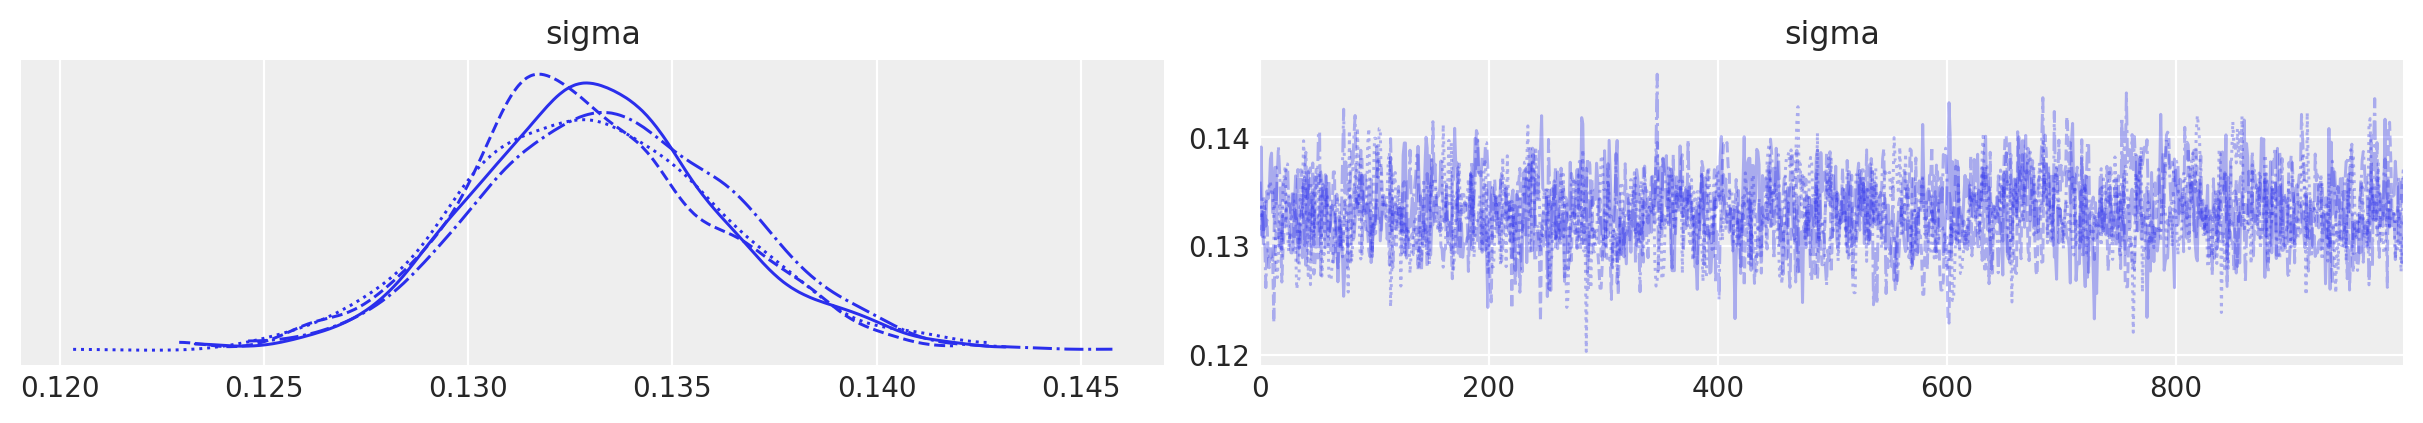

In [8]:
_ = az.plot_trace(idata, var_names=["sigma"])

The diagnostics for $\sigma$ are acceptable, with a bulk effective sample size in the hundreds and $\hat{R} < 1.01$. The tree ensemble requires more care. Each campaign's fitted value $f(x_i)$ is itself an MCMC quantity, and the warning printed by pymc after sampling is caused by the slowest-mixing of these fitted values, shown below.

In [9]:
leaf_summary = az.summary(idata, var_names=["bart"])
leaf_summary.sort_values("ess_bulk").head()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bart[c0852],0.107,0.038,0.036,0.176,0.008,0.001,25.0,341.0,1.13
bart[c0184],0.176,0.045,0.091,0.261,0.008,0.002,29.0,143.0,1.10
bart[c0997],0.427,0.039,0.356,0.500,0.007,0.001,30.0,391.0,1.11
bart[c0996],0.157,0.040,0.085,0.235,0.007,0.001,34.0,458.0,1.09
bart[c0189],0.475,0.035,0.405,0.535,0.006,0.001,34.0,298.0,1.09


A small number of fitted values mix an order of magnitude more slowly than the rest. For a tree ensemble this is somewhat expected as a BART posterior is a distribution over collections of trees, and two collections with different tree structures can represent nearly identical functions. For campaigns that lie close to a decision boundary, different chains can settle on different but functionally equivalent tree structures, which lowers the effective sample size of those campaigns' fitted values without making the predictions less reliable. Every quantity used in this notebook, such as a prediction, a ranking, or an average, combines the whole ensemble, so these combined quantities are the ones that need to be checked, which we do below.

In [10]:
bart_post = idata["posterior"]["bart"]
target_scale = float(np.abs(y_rct).max())

ensemble = bart_post.mean(dim="obs").to_dataset(name="ensemble_mean")
ess_ensemble = float(az.ess(ensemble)["ensemble_mean"])
rhat_ensemble = float(az.rhat(ensemble)["ensemble_mean"])
print(
    f"ensemble mean prediction: ess_bulk {ess_ensemble:,.0f}, r_hat {rhat_ensemble:.3f}"
)

chain_means = bart_post.mean(dim="draw") * target_scale
spread = chain_means.max(dim="chain") - chain_means.min(dim="chain")
print(
    "largest cross-chain disagreement in any fitted value: "
    f"{float(spread.max()):.3f} incremental conversions per $"
)

ensemble mean prediction: ess_bulk 3,954, r_hat 1.000
largest cross-chain disagreement in any fitted value: 0.082 incremental conversions per $


The ensemble-level diagnostics are good, and the four chains agree about every fitted value to within less than a tenth of a conversion per dollar, which is small enough that we should feel comfortable that the imperfections are tolerable.

As a final check, we map $\sigma$ back to the original scale. `PIEModel` standardises the target internally by dividing by its maximum absolute value, so if the model has captured the structure in the data, the rescaled $\sigma$ should match the simulated RCT measurement noise of 0.3.

In [11]:
sigma_hat = float(idata["posterior"]["sigma"].mean()) * target_scale
print(
    f"posterior mean of sigma, original scale: {sigma_hat:.3f}  (simulated RCT noise: {SIGMA_RCT})"
)

posterior mean of sigma, original scale: 0.284  (simulated RCT noise: 0.3)


## Understanding Incrementality Drivers

Before making predictions, we check which features the model relies on. `pymc_bart.compute_variable_importance` measures how much of the full ensemble's predictive $R^2$ is retained by submodels that are restricted to subsets of the features, where features are added in order of how often the trees split on them.

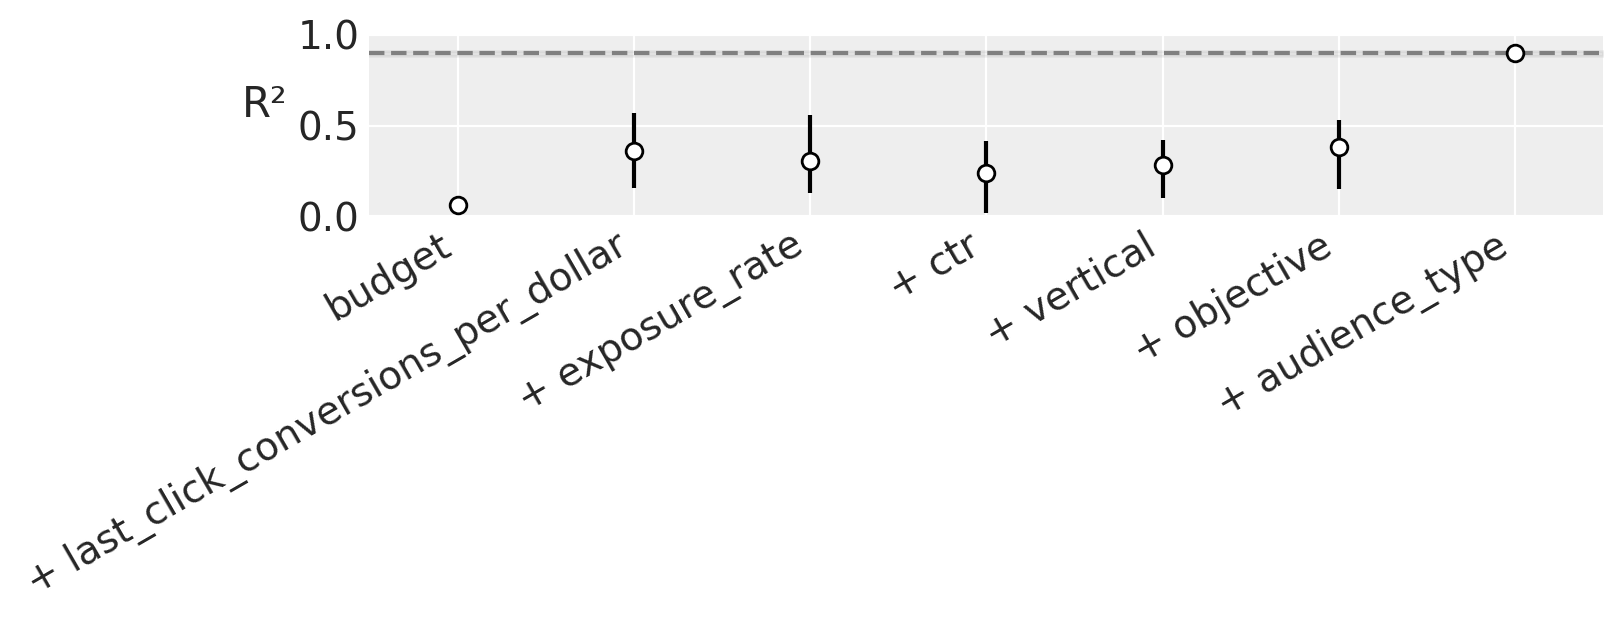

In [12]:
bart_rv = model.model["bart"]
features = pre_determined + post_determined
X_train_encoded = pd.DataFrame(model.model["X"].get_value(), columns=features)

vi_results = pmb.compute_variable_importance(
    idata,
    bart_rv,
    X_train_encoded,
    random_seed=seed,
)
ax = pmb.plot_variable_importance(vi_results, plot_kwargs={"rotation": 30})
_ = plt.setp(ax.get_xticklabels(), ha="right")

The most important features are the ones that the true incrementality function actually uses, namely audience type, exposure rate, last-click, and budget. `ctr`, which has no causal effect in the simulation, contributes essentially nothing.

The high importance of `last_click_conversions_per_dollar` does not contradict the earlier finding that last-click is a misleading ranking metric, because importance measures predictive value rather than causal effect. Last-click is informative once audience type is known, since a high value means something different for a retargeting campaign than for a prospecting campaign. The model combines last-click with audience type, and this combination is what corrects the bias in the raw metric.

### Counterfactual: Incrementality vs Budget

Because the model predicts incrementality from campaign features, we can ask questions that no single experiment answers, such as how a campaign's incrementality would change at a different budget. Below we construct a reference campaign with the conversions objective in the retail vertical, and predict its incrementality across a range of budgets for both audience types, holding all other features fixed.

One complication is that a counterfactual campaign has no post-determined features, because those only exist after a campaign runs. We set them to values consistent with the simulation. This situation is what the pre-determined versus post-determined distinction in the API is reserved for. The paper's solution, which is to predict from pre-determined features only, is not yet implemented in the alpha.

Sampling: [bart, y]


Sampling: [bart, y]


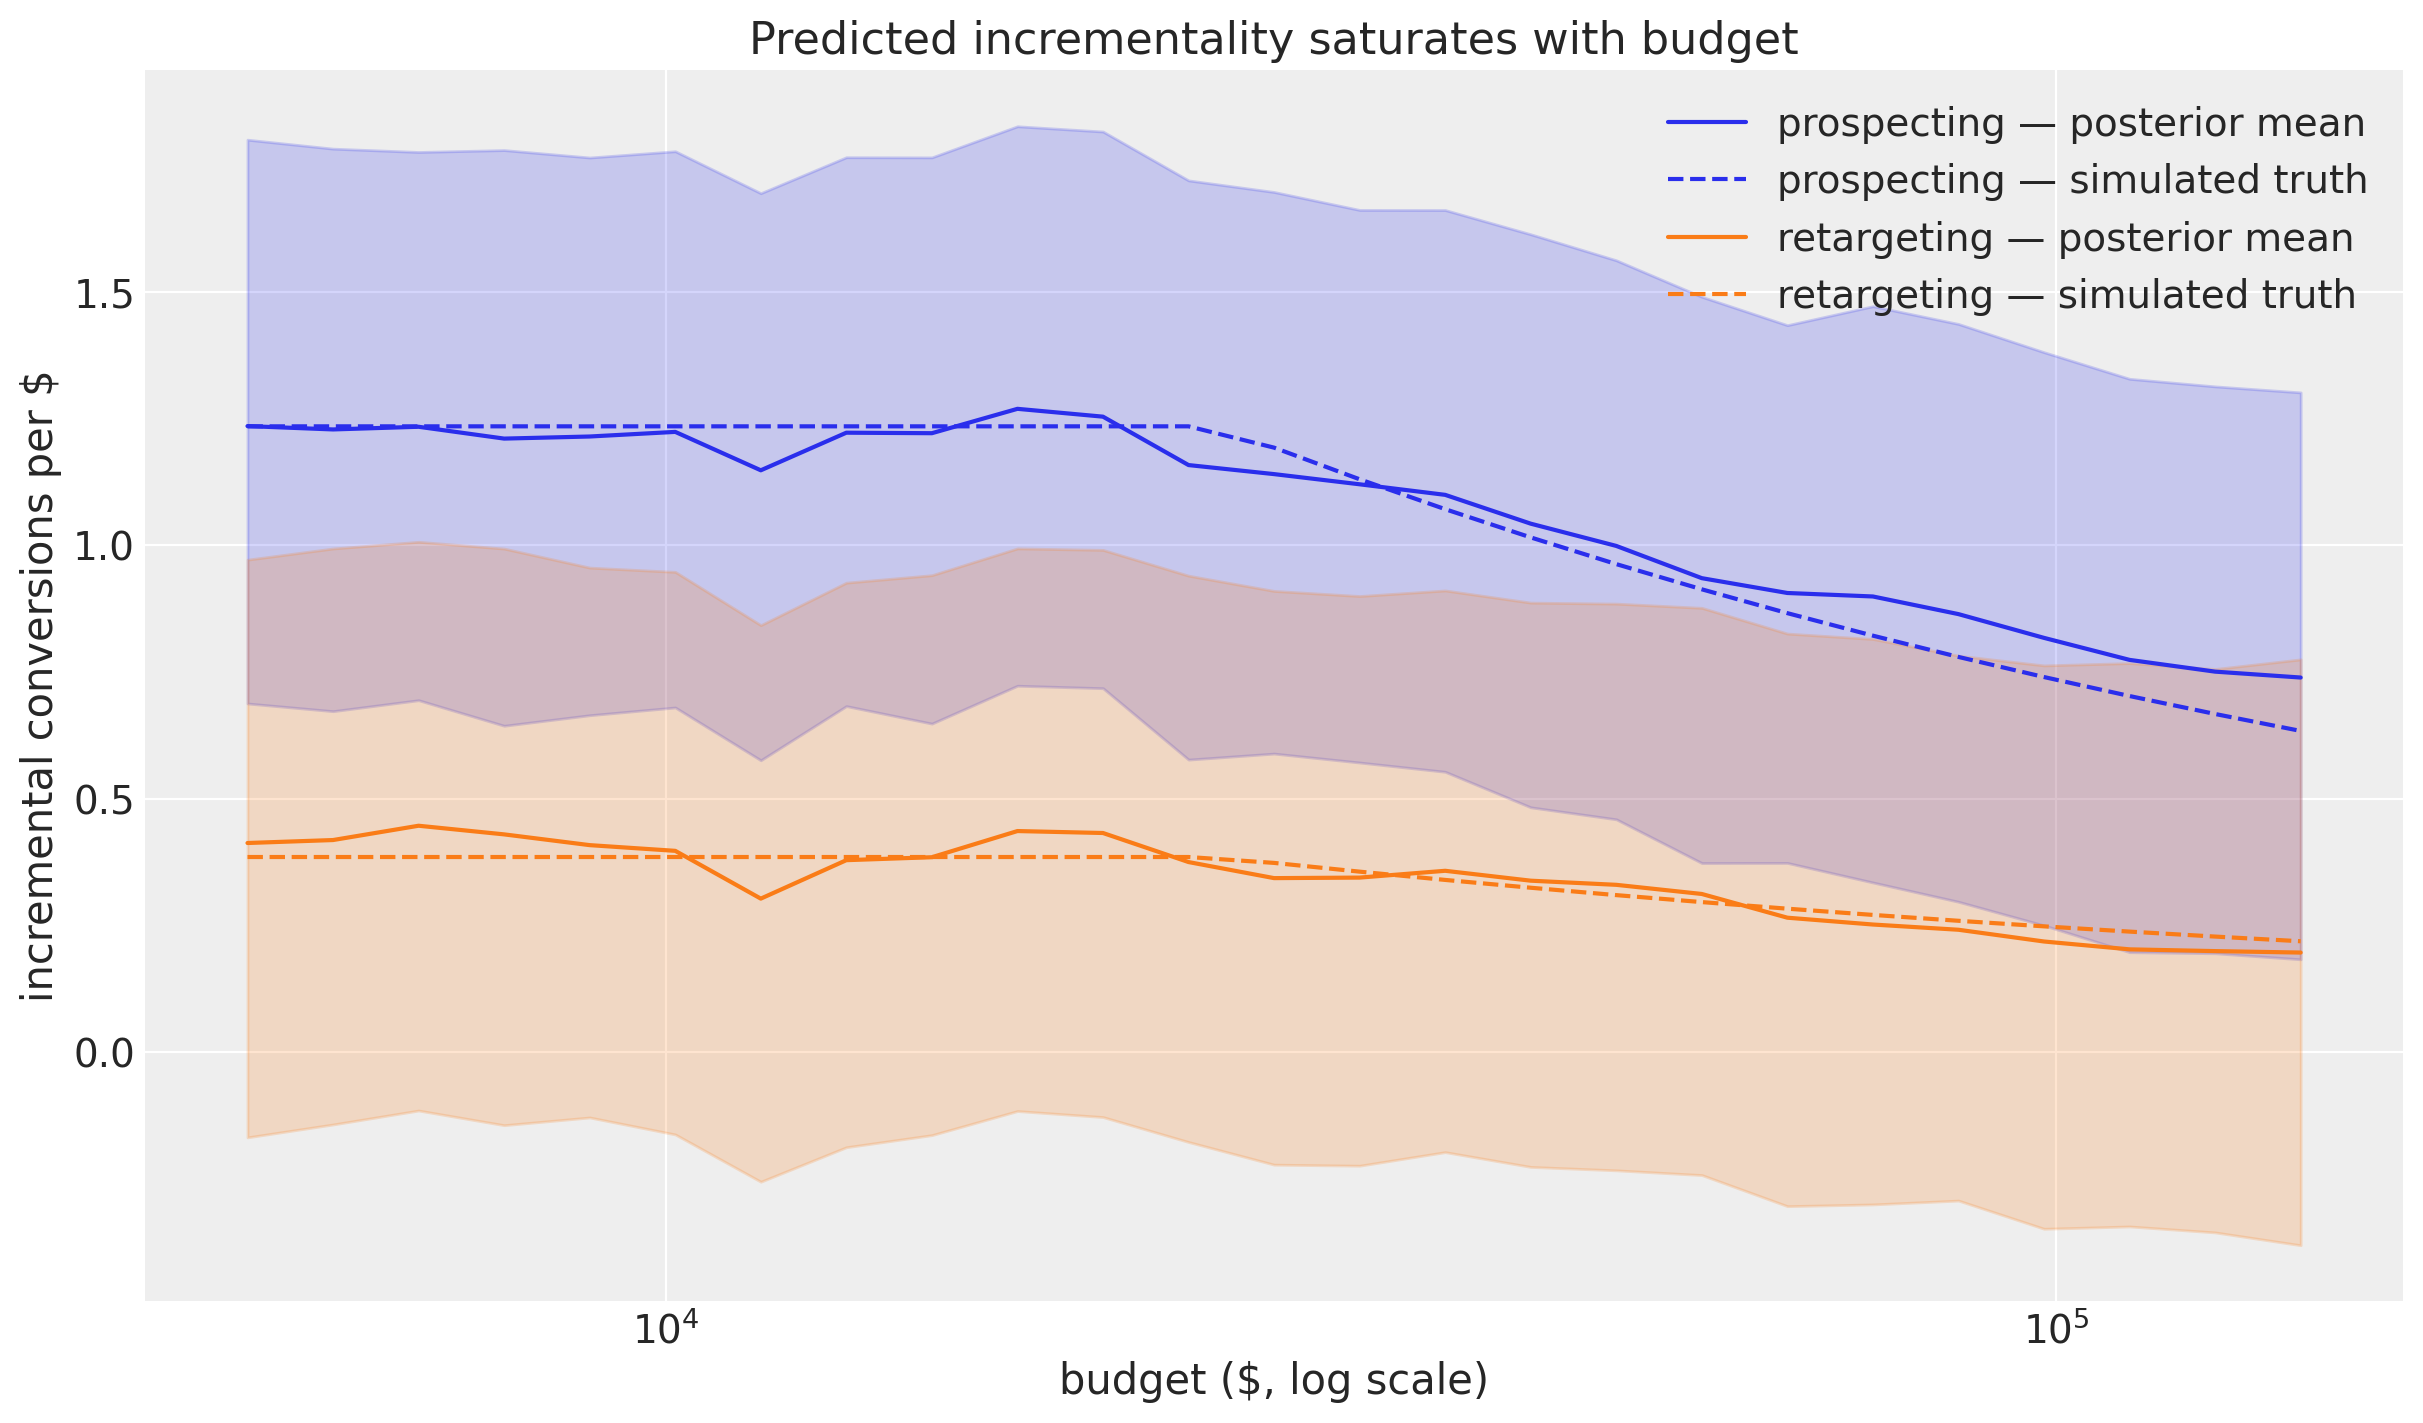

In [13]:
budgets = np.geomspace(5_000, 150_000, num=25).round(0)


def budget_sweep(audience: str) -> tuple[pd.DataFrame, np.ndarray]:
    """Replicate the reference campaign across budgets, with DGP-consistent post-determined features."""
    frame = pd.DataFrame(
        {
            "objective": "conversions",
            "vertical": "retail",
            "audience_type": audience,
            "budget": budgets,
            "exposure_rate": 0.5,
            "ctr": 0.015,
        },
        index=pd.Index(
            [f"sweep-{audience}-{i:02d}" for i in range(len(budgets))], name="campaign"
        ),
    )
    tau = true_incrementality(
        frame["objective"],
        frame["vertical"],
        frame["audience_type"],
        frame["budget"],
        frame["exposure_rate"],
    )
    attribution_bias = 0.9 if audience == "retargeting" else 0.05
    frame["last_click_conversions_per_dollar"] = 0.4 * tau + attribution_bias
    return frame, tau


fig, ax = plt.subplots()
for audience, color in colors.items():
    frame, tau_curve = budget_sweep(audience)
    draws = model.sample_posterior_predictive(
        frame, extend_idata=False, progressbar=False
    )
    mean = draws["y"].mean(dim="sample")
    q = draws["y"].quantile([0.03, 0.97], dim="sample")
    ax.plot(budgets, mean, color=color, label=f"{audience} — posterior mean")
    ax.fill_between(
        budgets, q.sel(quantile=0.03), q.sel(quantile=0.97), color=color, alpha=0.2
    )
    ax.plot(
        budgets,
        tau_curve,
        color=color,
        ls="--",
        lw=1.5,
        label=f"{audience} — simulated truth",
    )
ax.set(
    xscale="log",
    xlabel="budget ($, log scale)",
    ylabel="incremental conversions per $",
    title="Predicted incrementality saturates with budget",
)
_ = ax.legend()

The posterior mean tracks the true saturation curve for both audience types, and the persistent gap between prospecting and retargeting campaigns matches the audience effect in the data-generating process. The shaded bands are predictive intervals, which include the RCT measurement noise. They therefore describe the range of results that a geo test run at that budget would plausibly report, and not only the uncertainty about the function $f$.

## Predicting the Unmeasured Campaigns

We now predict incrementality for the 300 campaigns that never ran an experiment.

In [14]:
pred_draws = model.sample_posterior_predictive(X_new, progressbar=False)

pred_mean = pred_draws["y"].mean(dim="sample").values
pred_q = pred_draws["y"].quantile([0.03, 0.97], dim="sample")
pred_lo = pred_q.sel(quantile=0.03).values
pred_hi = pred_q.sel(quantile=0.97).values
truth = tau_new.values

Sampling: [bart, y]


### Scoring Against the Truth

The plot below compares the model's predictions with the true incrementality of each campaign. This comparison is only possible in a simulation, because true incrementality is never observed in practice.

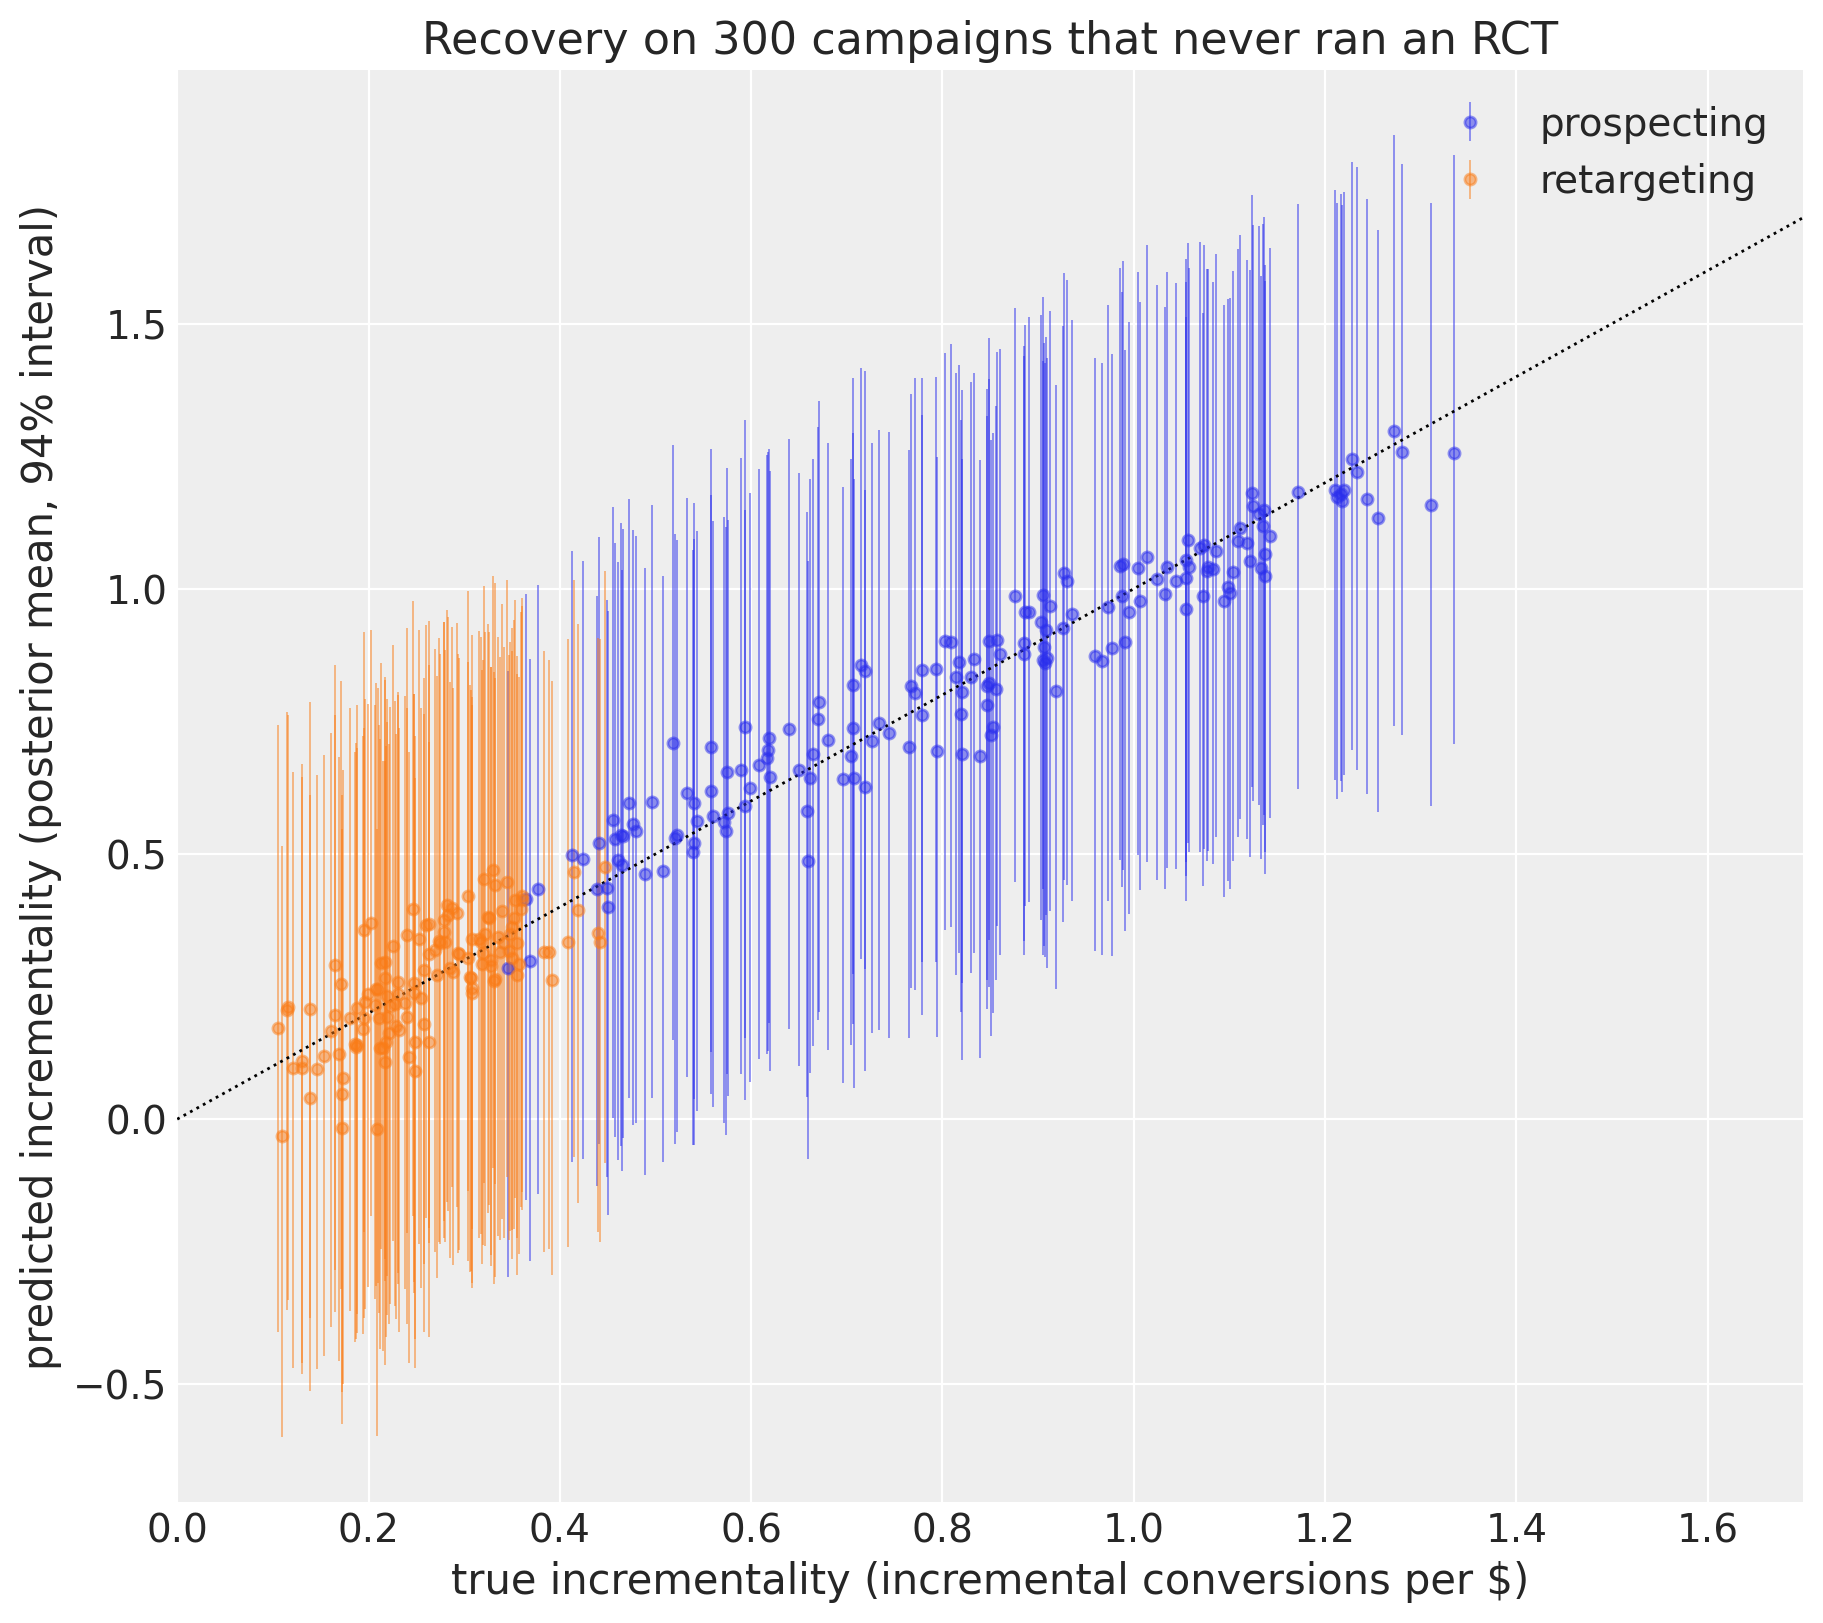

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
for audience, color in colors.items():
    mask = (X_new["audience_type"] == audience).to_numpy()
    ax.errorbar(
        truth[mask],
        pred_mean[mask],
        yerr=np.vstack(
            [pred_mean[mask] - pred_lo[mask], pred_hi[mask] - pred_mean[mask]]
        ),
        fmt="o",
        ms=4,
        color=color,
        elinewidth=0.7,
        alpha=0.5,
        label=audience,
    )
lims = (0.0, 1.7)
ax.plot(lims, lims, color="black", ls=":", lw=1)
ax.set(
    xlim=lims,
    xlabel="true incrementality (incremental conversions per $)",
    ylabel="predicted incrementality (posterior mean, 94% interval)",
    title="Recovery on 300 campaigns that never ran an RCT",
)
_ = ax.legend()

In [16]:
rmse_truth = float(np.sqrt(np.mean((pred_mean - truth) ** 2)))
corr_truth = float(np.corrcoef(pred_mean, truth)[0, 1])
coverage = float(np.mean((truth >= pred_lo) & (truth <= pred_hi)))

print(f"RMSE against truth:      {rmse_truth:.3f}")
print(f"correlation with truth:  {corr_truth:.3f}")
print(f"94% interval coverage of truth: {coverage:.1%}")

RMSE against truth:      0.071
correlation with truth:  0.978
94% interval coverage of truth: 100.0%


Coverage above the nominal 94% is expected rather than a problem. The predictive interval describes what an RCT would report, which is the true incrementality plus measurement noise, so the interval is wider than what is needed to cover the noise-free truth.

### What You Could Measure in Practice

On real data the true incrementality is not available, so the best possible validation is to hold out some measured campaigns and score the predictions against their noisy RCT readings. This is what the paper does. Because we simulated the data, we can quantify how much this approach understates the model's accuracy.

In [17]:
rmse_noisy = float(np.sqrt(np.mean((pred_mean - y_new_hypothetical.values) ** 2)))
implied = float(np.sqrt(rmse_truth**2 + SIGMA_RCT**2))

print(f"RMSE against hypothetical RCT readings: {rmse_noisy:.3f}")
print(f"sqrt(RMSE_truth² + sigma_RCT²):         {implied:.3f}")

RMSE against hypothetical RCT readings: 0.303
sqrt(RMSE_truth² + sigma_RCT²):         0.308


The two numbers agree because holdout error decomposes as $\text{RMSE}^2_{\text{holdout}} \approx \text{RMSE}^2_{\text{truth}} + \sigma_{\mathrm{RCT}}^2$. On real data, a substantial share of holdout error is therefore irreducible experiment noise rather than model error, and holdout RMSE should not be interpreted as the distance between the predictions and the truth.

## Selecting Campaigns to Scale Up

Suppose next quarter's plan is to scale up 60 of the 300 unmeasured campaigns. We compare three ways of choosing the 60 campaigns. The first ranks campaigns by the last-click metric, the second ranks them by PIE's posterior mean prediction, and the third ranks them by true incrementality. The third rule is impossible to apply in practice and serves as the best-case benchmark.

In [18]:
K = 60
pie_score = pd.Series(pred_mean, index=X_new.index)

picks = {
    "last-click": X_new["last_click_conversions_per_dollar"].nlargest(K).index,
    "PIE": pie_score.nlargest(K).index,
    "oracle": tau_new.nlargest(K).index,
}

selection_summary = pd.DataFrame(
    {
        name: {
            "mean true incrementality of picks": tau_new[idx].mean(),
            "overlap with true top-60": len(set(idx) & set(picks["oracle"])),
            "share retargeting": (
                X_new.loc[idx, "audience_type"] == "retargeting"
            ).mean(),
        }
        for name, idx in picks.items()
    }
).T.round(3)
selection_summary

,mean true incrementality of picks,overlap with true top-60,share retargeting
last-click,0.286,0.0,1.0
PIE,1.099,55.0,0.0
oracle,1.103,60.0,0.0


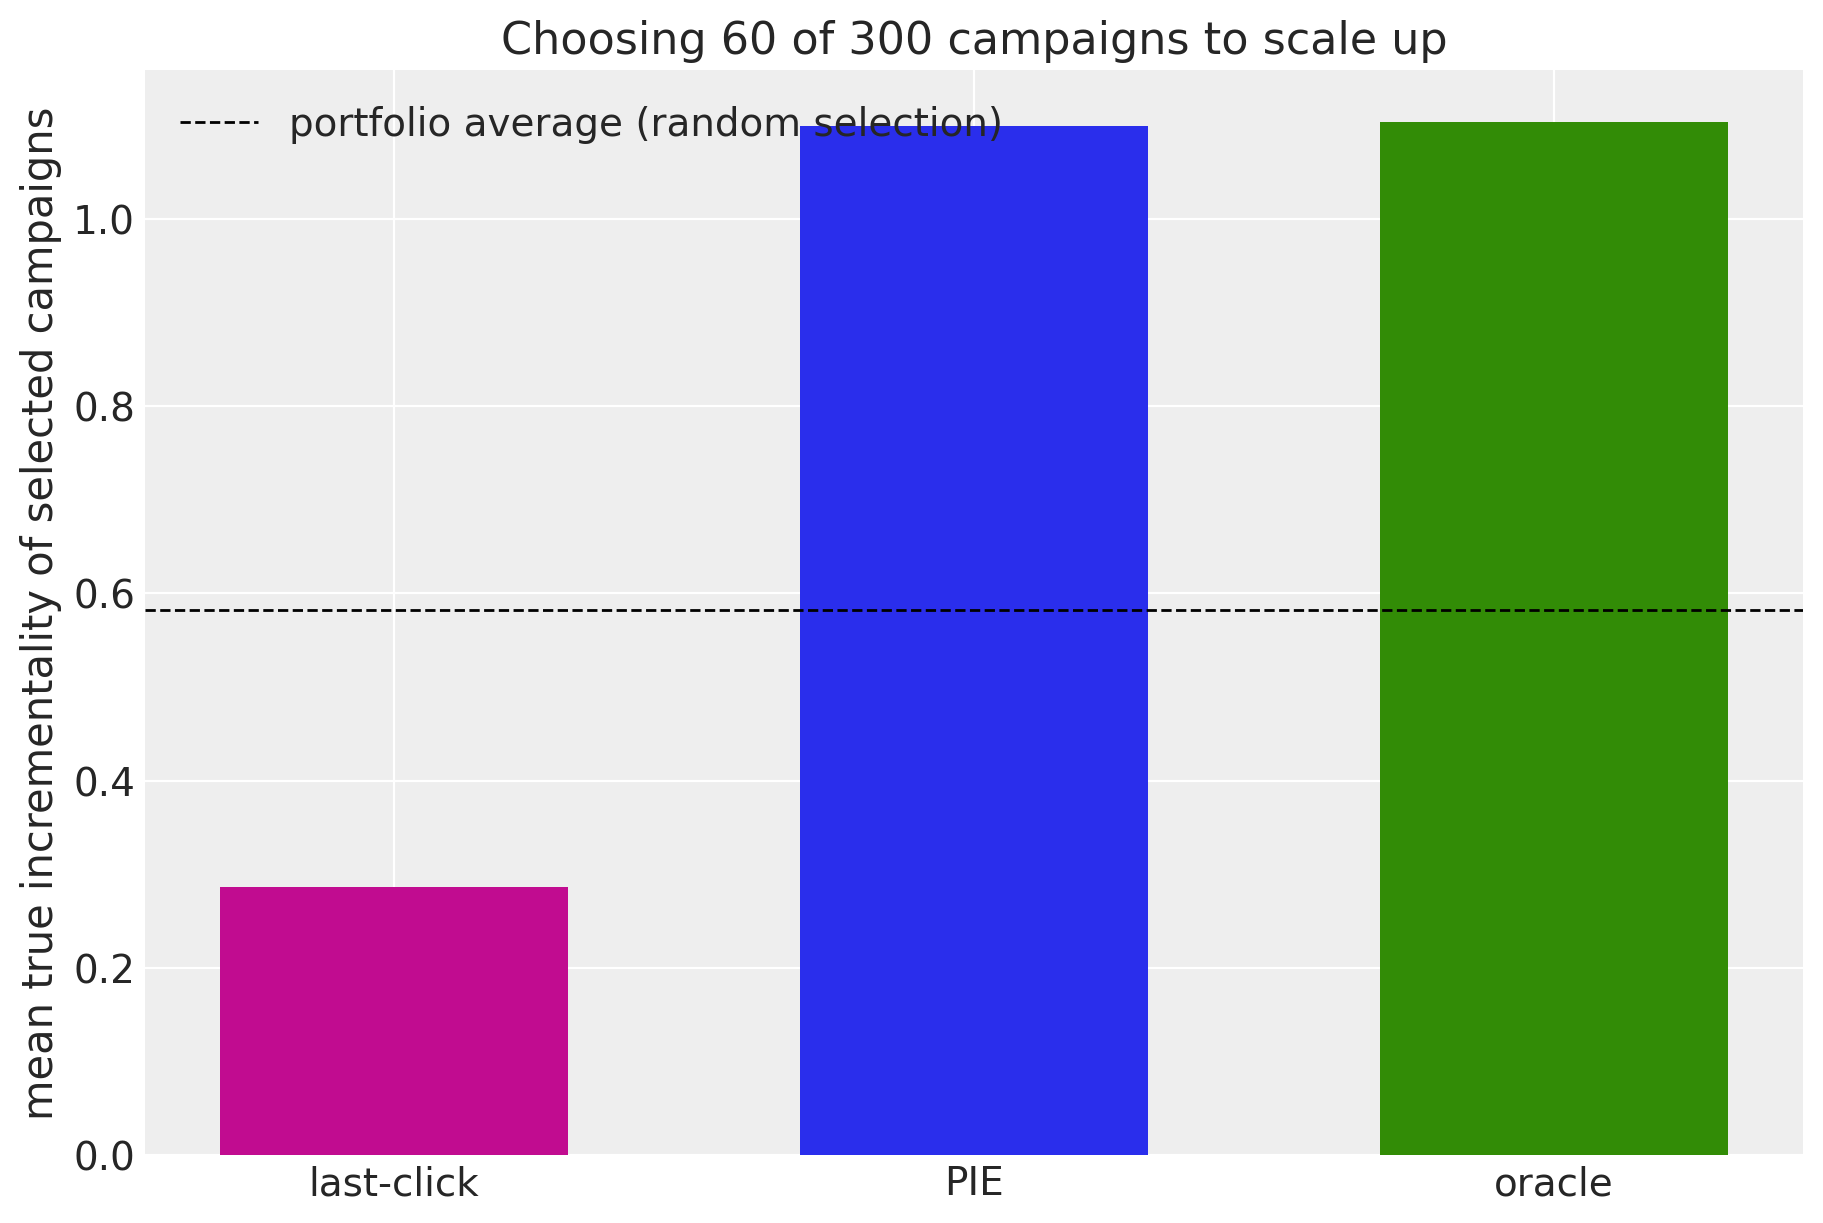

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(
    list(picks),
    [tau_new[idx].mean() for idx in picks.values()],
    color=["C3", "C0", "C2"],
    width=0.6,
)
ax.axhline(
    tau_new.mean(),
    color="black",
    ls="--",
    lw=1,
    label="portfolio average (random selection)",
)
ax.set(
    ylabel="mean true incrementality of selected campaigns",
    title=f"Choosing {K} of 300 campaigns to scale up",
)
_ = ax.legend()

Selecting by last-click performs worse than selecting at random, because it concentrates the budget on retargeting campaigns, whose last-click numbers mostly reflect conversions that would have happened anyway. Selecting by PIE's predictions recovers most of the campaigns with the highest true incrementality, even though last-click is one of the model's inputs. The model learned that the meaning of last-click depends on audience type, so the feature did not need to be removed.

```{note}
On real data one caveat applies to this comparison. Post-determined features and the RCT's incrementality estimate are computed from the same campaign data, which can create a mechanical correlation between them. The paper removes this correlation with within-campaign sample splitting (§4.2), which this alpha does not implement. The simulation is not affected because the measurement noise is drawn independently of every feature, but on real data this comparison should only be trusted when sample splitting is in place.
```

(pie_alpha_status)=
## What the Alpha Does Not Yet Implement

`PIEModel` implements the paper's core approach with the following deviations:

- **BART instead of a random forest:** a deliberate change. Because the ensemble is sampled, predictions carry posterior uncertainty without the need for bootstrap approximations.
- **No decision-theoretic layer (paper §6):** the paper turns predictions into go/no-go decisions with explicit Type I/II error trade-offs. In this release that analysis must be done manually, as in the selection exercise above.
- **No within-campaign sample splitting (paper §4.2):** needed on real data to remove the mechanical correlation between post-determined features and the RCT estimate, as described in the note above.
- **No extrapolation / cold-start diagnostics (paper §5.3):** predictions for campaigns far outside the corpus's feature support are extrapolations, and the model does not yet warn when that happens.
- **No measurement-error layer:** each RCT's standard error could enter the likelihood as $y_{\text{obs}} \sim \mathrm{Normal}(y_{\text{true}}, \mathrm{se}_{\text{rct}})$. Currently a single $\sigma$ is shared across the corpus.

See the {class}`~pymc_marketing.pie.PIEModel` docstring for the authoritative list.

## Appendix: Configuring the Model

`model_config` overrides the defaults returned by `PIEModel.default_model_config`:

- `"bart"`: `m` (number of trees), `alpha`/`beta` (tree-depth prior), and optionally `response` (`"constant"`, `"linear"`, or `"mix"`; the latter two fit linear leaves, which can help on smooth surfaces).
- `"sigma"`: a `pymc_extras.prior.Prior` for the noise scale.
- `"categorical_split"`: `"onehot"` (default) or `"continuous"` for label-encoded categorical columns.

One caveat is that top-level keys merge with the defaults while nested dicts are replaced wholesale, so a partial `"bart"` override must restate every required key (`m`, `alpha`, `beta`). As a quick sensitivity check, here is a lighter 50-tree ensemble on the same corpus:

In [20]:
model_small = PIEModel(
    pre_determined_features=pre_determined,
    post_determined_features=post_determined,
    model_config={
        "bart": {"m": 50, "alpha": 0.95, "beta": 2.0},
    },
    sampler_config={"tune": 500, "draws": 500, "chains": 2},
)
_ = model_small.fit(X_rct, y_rct, random_seed=seed, progressbar=False)

pred_small = model_small.sample_posterior_predictive(
    X_new, extend_idata=False, progressbar=False
)
rmse_small = float(
    np.sqrt(np.mean((pred_small["y"].mean(dim="sample").values - truth) ** 2))
)
print(
    f"RMSE vs truth — default (m=200): {rmse_truth:.3f} | small (m=50): {rmse_small:.3f}"
)

Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>PGBART: [bart]


>NUTS: [sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 12 seconds.


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Sampling: [bart, y]


RMSE vs truth — default (m=200): 0.071 | small (m=50): 0.064


On a response surface as simple as this simulation, an ensemble with a quarter of the trees performs comparably to the default at a fraction of the sampling time. The smaller ensemble is useful for fast iteration, while the default is a safer choice when the shape of the response surface is unknown.

In [21]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc,pytensor,pymc_bart

Last updated: Sat, 18 Jul 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc     : 5.28.5
pytensor : 2.38.2
pymc_bart: 0.11.0

arviz         : 0.23.4
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_bart     : 0.11.0
pymc_marketing: 0.19.4
scipy         : 1.18.0

Watermark: 2.6.0

